In [1]:
import os
from PIL import Image
from torchvision import transforms
from tqdm import tqdm


In [2]:
INPUT_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset"
OUTPUT_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset_preprocessed"

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [4]:
def preprocess_and_save(split):
    for label in ["Fake", "Real"]:
        input_path = os.path.join(INPUT_DIR, split, label)
        output_path = os.path.join(OUTPUT_DIR, split, label)
        os.makedirs(output_path, exist_ok=True)

        for img_name in tqdm(os.listdir(input_path), desc=f"{split}-{label}"):
            img_path = os.path.join(input_path, img_name)

            try:
                img = Image.open(img_path).convert("RGB")
                img_tensor = preprocess(img)

                # Convert back to image for saving
                img_save = transforms.ToPILImage()(img_tensor)
                img_save.save(os.path.join(output_path, img_name))

            except Exception as e:
                print(f"Error processing {img_path}: {e}")


In [5]:
for split in ["Train", "Val", "Test"]:
    preprocess_and_save(split)

print("✅ All images preprocessed and saved successfully!")


Train-Real:   2%|█▏                                                                    | 7/422 [00:02<01:59,  3.48it/s]

Error processing C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset\Train\Real\image (1).ini: cannot identify image file 'C:\\Users\\nshre\\OneDrive\\Desktop\\Vision-Based-Fake-Medicine-Detection\\dataset\\Train\\Real\\image (1).ini'


Val-Real:   3%|██▍                                                                    | 10/287 [00:00<00:05, 48.60it/s]

Error processing C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset\Val\Real\image (1).ini: cannot identify image file 'C:\\Users\\nshre\\OneDrive\\Desktop\\Vision-Based-Fake-Medicine-Detection\\dataset\\Val\\Real\\image (1).ini'


Test-Real: 100%|█████████████████████████████████████████████████████████████████████| 287/287 [00:05<00:00, 55.45it/s]

✅ All images preprocessed and saved successfully!


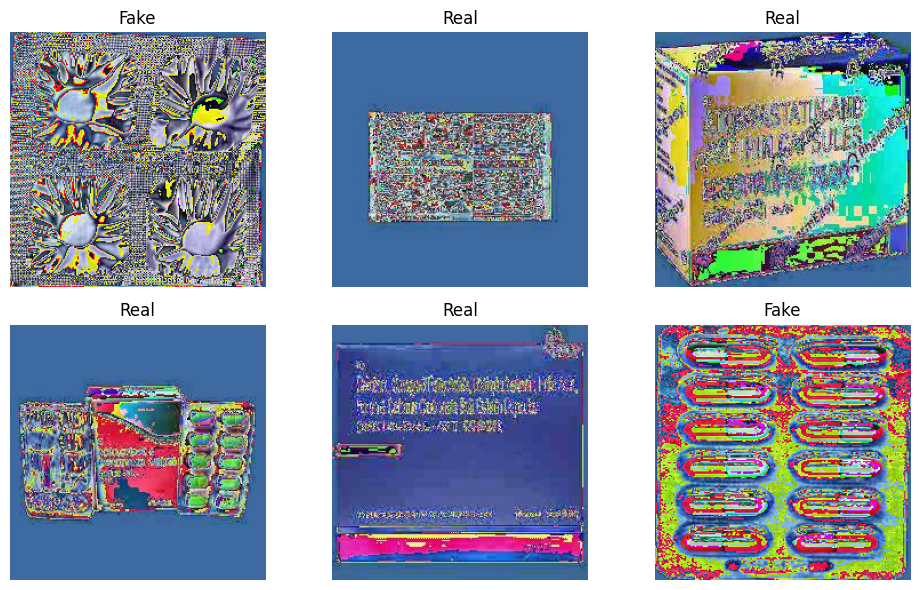

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
PREPROCESSED_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset_preprocessed\Train"

classes = ["Fake", "Real"]

plt.figure(figsize=(10, 6))

for i in range(6):
    cls = random.choice(classes)
    cls_path = os.path.join(PREPROCESSED_DIR, cls)

    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()
